In [1]:
import pandas as pd
import matplotlib.pyplot as plt

import datetime as dt


In [ ]:
pip install kagglehub

# Load data

In [2]:
import kagglehub
from kagglehub import KaggleDatasetAdapter

file_path = "2019-Oct.csv"

# Loading dataset with pandas kwargs
df = kagglehub.load_dataset(
KaggleDatasetAdapter.PANDAS,
"mkechinov/ecommerce-behavior-data-from-multi-category-store",
"2019-Oct.csv",
pandas_kwargs={
"nrows": 500_000,
"dtype": {
'event_type': 'category',
'product_id': 'int32',
'category_code': 'category',
'brand': 'category',
'price': 'float32',
'user_id': 'int32',
}
}
)


/home/sophie/.pyenv/versions/3.10.6/envs/convertiq/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/tmp/ipykernel_169425/1897145881.py:7: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(


In [3]:
df = df.drop_duplicates()

In [4]:
df.shape

(499712, 9)

In [3]:
df['event_time'] = pd.to_datetime(df['event_time'])

In [4]:
cut_time = df['event_time'].median()

In [5]:
cut_time

Timestamp('2019-10-01 06:52:15+0000', tz='UTC')

In [6]:
past   = df[df['event_time'] <= cut_time]
future = df[df['event_time'] >  cut_time]

In [5]:
list_category_code = ['electronics.smartphone',
'electronics.audio.headphone',
'electronics.clocks',
'computers.notebook',
'electronics.video.tv'
]


In [6]:
df_elec=df[df['category_code'].isin(list_category_code)]

In [ ]:
df_elec['date'] = df_elec['event_time'].apply(lambda s : str(s)[0:10])

In [ ]:
df_elec['hour'] = df_elec['event_time'].apply(lambda s : str(s)[10:19])

In [ ]:

df_elec['date'] = pd.to_datetime(df_elec['date'])

In [ ]:
df_elec['week_of_day'] = df_elec['date'].dt.day_name()

In [7]:
df_elec['event_type_str'] = df_elec['event_type'].astype(str)
df_elec.sort_values(by=['user_id', 'user_session', 'product_id', 'event_time'])
df_elec['event_time']=pd.to_datetime(df_elec['event_time'])


/tmp/ipykernel_169425/1888376266.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_elec['event_type_str'] = df_elec['event_type'].astype(str)
/tmp/ipykernel_169425/1888376266.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_elec['event_time']=pd.to_datetime(df_elec['event_time'])


In [ ]:

df_events_v2 = df_elec.groupby(['user_id', 'user_session'])['event_type_str'].apply(lambda x: pd.Series([x.iloc[i] if i < len(x) else ' ' for i in range(8)
              ], index=['event1', 'event2', 'event3','event4', 'event5', 'event6','event7', 'event8' ])).reset_index()
df_events_v2.pivot(index=['user_id', 'user_session'], columns='level_2', values='event_type_str')
df_events_v2.head(10)

In [11]:
df_elec['event_time'] = df_elec['event_time'].astype(str)

/tmp/ipykernel_6220/1570059409.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_elec['event_time'] = df_elec['event_time'].astype(str)


In [ ]:
df_events_v2_pivot = df_events_v2.pivot(index=['user_id', 'user_session'], columns='level_2', values='event_type_str').reset_index()

In [ ]:
df_events_v2_pivot.head(10)

#Buliding sequence of events

In [ ]:
#time sequence per user id, user session
df_events_time = df_elec.groupby(['user_id', 'user_session'])['event_time'].apply(lambda x: pd.Series([x.iloc[i] if i < len(x) else ' ' for i in range(8)
              ], index=['time1', 'time2', 'time3','time4', 'time5', 'time6','time7', 'time8' ])).reset_index()
df_events_time_pivot = df_events_time.pivot(index=['user_id', 'user_session'], columns='level_2', values='event_time').reset_index()
df_events_time_pivot.head(10)

In [8]:
#event sequence and duration mean per user id, user session
import numpy as np
df_events = df_elec.groupby(['user_id', 'user_session', 'category_id']).agg({
    'event_type_str' : " ".join,
    'event_time' : (lambda x : max(x) - min(x)),
    'product_id' : (lambda x : np.size(x))
}).reset_index()

In [9]:
df_events['seq_list'] = df_events['event_type_str'].apply(str.split)
df_events['seq_list_1'] = df_events['seq_list'].apply(lambda x : x[:-1])
df_events['target'] = df_events['seq_list'].apply(lambda x : x[-1])
df_events['seq_one'] = df_events['seq_list_1'].apply(lambda x : ['one_view'] if x==[] else x)
df_events['seq'] = df_events.agg({'seq_one' : " ".join })




#df_events['seq_1'] = df_events.groupby(['user_id', 'user_session'])['seq_list'].apply(lambda x: x[:-1])

#df_events_time['target'] = df_events.groupby(['user_id', 'user_session'])['event_type_str'].apply(lambda x: x[-1])

/tmp/ipykernel_169425/204725043.py:5: FutureWarning: using <built-in method join of str object at 0x711143db3f30> in Series.agg cannot aggregate and has been deprecated. Use Series.transform to keep behavior unchanged.
  df_events['seq'] = df_events.agg({'seq_one' : " ".join })


In [10]:
df_events = df_events.rename(columns={'event_time':'duration', 'product_id' : 'nb_product'})

In [11]:
df_events['sequence_len'] = df_events['seq'].apply(lambda x : len(x.split()))
df_events['duration_mean']=df_events['duration']/df_events['sequence_len']
df_events['duration_mean_sec'] = df_events['duration_mean'].dt.total_seconds()

In [12]:
df_events.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 55094 entries, 0 to 55093
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype          
---  ------             --------------  -----          
 0   user_id            55094 non-null  int32          
 1   user_session       55094 non-null  object         
 2   category_id        55094 non-null  int64          
 3   event_type_str     55094 non-null  object         
 4   duration           55094 non-null  timedelta64[ns]
 5   nb_product         55094 non-null  int64          
 6   seq_list           55094 non-null  object         
 7   seq_list_1         55094 non-null  object         
 8   target             55094 non-null  object         
 9   seq_one            55094 non-null  object         
 10  seq                55094 non-null  object         
 11  sequence_len       55094 non-null  int64          
 12  duration_mean      55094 non-null  timedelta64[ns]
 13  duration_mean_sec  55094 non-null  float64    

In [13]:
df_price = df_elec.groupby(['user_id', 'user_session', 'category_id']).agg(
    price_median=('price', 'median'),
    price_iqr=('price', lambda x: x.quantile(0.75) - x.quantile(0.25)),
    price_max=('price', 'max'),
    price_min=('price', 'min')
)

In [14]:
df_price['price_dispersion'] = df_price['price_iqr'] / df_price['price_median']
df_price['price_range'] = df_price['price_max'] - df_price['price_min']

In [15]:
df_price.shape

(55094, 6)

In [16]:
df_price.info()

<class 'pandas.core.frame.DataFrame'>
MultiIndex: 55094 entries, (np.int32(244951053), '91769fdf-461b-4e43-9c73-88a07481b75c', np.int64(2053013555631882655)) to (np.int32(555584028), '9947dc97-9691-4bf4-abf7-a37c8a411e0d', np.int64(2053013555631882655))
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   price_median      55094 non-null  float32
 1   price_iqr         55094 non-null  float64
 2   price_max         55094 non-null  float32
 3   price_min         55094 non-null  float32
 4   price_dispersion  55070 non-null  float64
 5   price_range       55094 non-null  float32
dtypes: float32(4), float64(2)
memory usage: 2.7+ MB


In [17]:
df_events.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 55094 entries, 0 to 55093
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype          
---  ------             --------------  -----          
 0   user_id            55094 non-null  int32          
 1   user_session       55094 non-null  object         
 2   category_id        55094 non-null  int64          
 3   event_type_str     55094 non-null  object         
 4   duration           55094 non-null  timedelta64[ns]
 5   nb_product         55094 non-null  int64          
 6   seq_list           55094 non-null  object         
 7   seq_list_1         55094 non-null  object         
 8   target             55094 non-null  object         
 9   seq_one            55094 non-null  object         
 10  seq                55094 non-null  object         
 11  sequence_len       55094 non-null  int64          
 12  duration_mean      55094 non-null  timedelta64[ns]
 13  duration_mean_sec  55094 non-null  float64    

In [ ]:
#df_events['event_time_list'] = df_events['event_time'].apply(str.split)
#df_events['event_time_1'] = df_events['event_time_list'].apply(lambda x : x[:-1])
#df_events['time_to target'] = df_events['event_time_list'].apply(lambda x : x[-1])
#df_events['seq'] = df_events.agg({'seq_list_1' : " ".join })

In [18]:
df_events.shape

(55094, 14)

In [19]:
df_events_price = pd.merge(df_events, df_price, on = ['user_id', 'user_session', 'category_id'])

In [20]:
df_events_price.shape

(55094, 20)

In [ ]:
#df_events_2 = pd.merge(df_events, df_elec.loc[:,['user_id', 'user_session', 'product_id', 'event_time']], on=['user_id', 'user_session', 'product_id'], how='left')

In [21]:
df_events_price.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 55094 entries, 0 to 55093
Data columns (total 20 columns):
 #   Column             Non-Null Count  Dtype          
---  ------             --------------  -----          
 0   user_id            55094 non-null  int32          
 1   user_session       55094 non-null  object         
 2   category_id        55094 non-null  int64          
 3   event_type_str     55094 non-null  object         
 4   duration           55094 non-null  timedelta64[ns]
 5   nb_product         55094 non-null  int64          
 6   seq_list           55094 non-null  object         
 7   seq_list_1         55094 non-null  object         
 8   target             55094 non-null  object         
 9   seq_one            55094 non-null  object         
 10  seq                55094 non-null  object         
 11  sequence_len       55094 non-null  int64          
 12  duration_mean      55094 non-null  timedelta64[ns]
 13  duration_mean_sec  55094 non-null  float64    

In [22]:
df_events_price['target'].value_counts()

target
view        52301
purchase     2005
cart          788
Name: count, dtype: int64

In [23]:
df_events_price['target_0_1'] = df_events_price['target'].apply(lambda x : 1 if x=='purchase' else 0)

In [24]:
df_events_price['target_0_1'].value_counts(normalize=True)

target_0_1
0    0.963608
1    0.036392
Name: proportion, dtype: float64

In [25]:
df_events_price.describe()

,user_id,category_id,duration,nb_product,sequence_len,duration_mean,duration_mean_sec,price_median,price_iqr,price_max,price_min,price_dispersion,price_range,target_0_1
count,5.509400e+04,5.509400e+04,55094,55094.000000,55094.000000,55094,55094.000000,55094.000000,55094.000000,55094.000000,55094.000000,55070.000000,55094.000000,55094.000000
mean,5.335460e+08,2.053047e+18,0 days 00:03:56.660525647,3.486786,2.881294,0 days 00:01:16.713426808,76.713427,485.897095,58.517173,573.734619,434.563904,0.151892,139.170807,0.036392
std,1.710318e+07,1.372117e+15,0 days 00:15:40.172830893,4.548015,4.354442,0 days 00:09:25.750043107,565.750043,436.075317,147.994638,512.550598,412.024872,1.026344,315.959290,0.187266
min,2.449511e+08,2.053014e+18,0 days 00:00:00,1.000000,1.000000,0 days 00:00:00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,5.164016e+08,2.053014e+18,0 days 00:00:00,1.000000,1.000000,0 days 00:00:00,0.000000,171.559998,0.000000,185.057503,150.699997,0.000000,0.000000,0.000000
50%,5.326711e+08,2.053014e+18,0 days 00:00:40,2.000000,1.000000,0 days 00:00:22.600000,22.600000,301.079987,0.000000,370.410004,257.149994,0.000000,0.000000,0.000000
75%,5.516653e+08,2.053014e+18,0 days 00:02:55,4.000000,3.000000,0 days 00:00:55.813636363,55.813636,736.179993,38.610012,900.640015,621.440002,0.141254,107.790009,0.000000
max,5.555840e+08,2.109094e+18,0 days 08:59:23,139.000000,138.000000,0 days 08:59:23,32363.000000,2574.070068,2379.230095,2574.070068,2574.070068,183.011356,2557.340088,1.000000


In [26]:
#building of y dataframe
y = df_events_price['target_0_1']
#y_small = pd.DataFrame(df_event_feature_small['target_0_1'])

In [27]:
y.shape

(55094,)

In [29]:
X = df_events_price.loc[:,['category_id', 'seq','duration_mean_sec', 'sequence_len', 'nb_product', 'price_dispersion', 'price_median' ]]

In [37]:
X.isnull().sum()

category_id           0
seq                   0
duration_mean_sec     0
sequence_len          0
nb_product            0
price_dispersion     24
price_median          0
dtype: int64

In [30]:
X.head(5)

,category_id,seq,duration_mean_sec,sequence_len,nb_product,price_dispersion,price_median
0,2053013555631882655,view,53.00,1,2,0.000000,460.500000
1,2053013555631882655,view view,123.50,2,3,0.462062,241.179993
2,2053013554658804075,view view,112.00,2,3,0.086118,161.929993
3,2053013555631882655,view view view cart,38.25,4,5,0.062981,197.520004
4,2053013554658804075,one_view,0.00,1,1,0.000000,188.729996


In [58]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state = 42, stratify=y)

In [40]:
from sklearn.pipeline import Pipeline, FunctionTransformer
from sklearn.compose import ColumnTransformer, make_column_selector

from sklearn.preprocessing import OneHotEncoder, RobustScaler
from sklearn.impute import SimpleImputer
pipe_cat = Pipeline([('ohe',OneHotEncoder(sparse_output=False,

                        handle_unknown="ignore").set_output(transform="pandas"))])


In [ ]:
pipe_num = Pipeline([('simple_impute', SimpleImputer(missing_values=np.nan, strategy='mean')),
                     ('rb_scale', RobustScaler().set_output(transform="pandas"))])

In [42]:
col_transf = ColumnTransformer([
    ('cat_transform',pipe_cat, ["category_id", "seq"]),
    ('num_transform', pipe_num, ['sequence_len', 'duration_mean_sec', 'nb_product', 'price_dispersion', 'price_median'])
])

In [43]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_validate, cross_val_predict, cross_val_score
pipe = Pipeline([
    ("preprocessing", col_transf),
    ("classifier", LogisticRegression(max_iter=1000, class_weight='balanced'))
])

In [59]:
cv_result = cross_validate(pipe, X_train, y_train, cv = 5, scoring = ['precision', 'recall', 'f1'])

In [45]:
cv_result.keys()

dict_keys(['fit_time', 'score_time', 'test_precision', 'test_recall', 'test_f1'])

In [60]:
cv_result['test_f1'].mean()

np.float64(0.22243636247384635)

In [61]:
cv_result['test_recall'].mean()

np.float64(0.8148500778816199)

In [62]:
cv_result['test_precision'].mean()

np.float64(0.12881654408298923)

# Baseline model Regression Logistique

In [63]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_validate, cross_val_predict, cross_val_score


model = pipe.fit(X_train, y_train)


In [64]:
from sklearn.metrics import classification_report
print(classification_report(y_test, pipe.predict(X_test)))

              precision    recall  f1-score   support

           0       0.99      0.79      0.88     10618
           1       0.12      0.80      0.22       401

    accuracy                           0.79     11019
   macro avg       0.56      0.79      0.55     11019
weighted avg       0.96      0.79      0.85     11019



### PR-AUC

In [52]:
from sklearn.metrics import precision_recall_curve
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import cross_val_score
from sklearn.metrics import PrecisionRecallDisplay, precision_recall_curve

cv = StratifiedKFold(n_splits=5)
cross_v_result = cross_val_score(pipe, X_train, y_train, cv=cv, scoring="average_precision").mean()


In [53]:
cross_v_result

np.float64(0.37472104604176526)

In [54]:
y_pred_prob = pipe.predict_proba(X_test)


In [55]:
y_pred_prob= y_pred_prob[:,1]

In [56]:
precision, recall, _= precision_recall_curve(y_test, y_pred_prob)

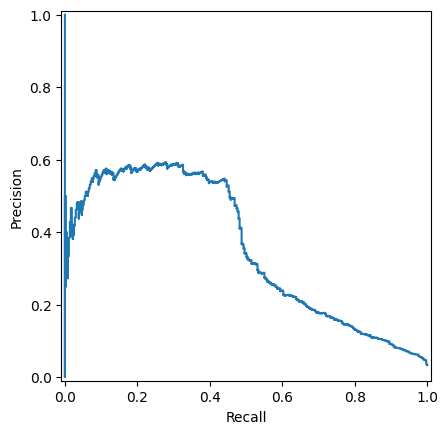

In [57]:

disp = PrecisionRecallDisplay(precision=precision, recall=recall)
disp.plot();

In [ ]:
cross_v_result

np.float64(0.3634476473578629)

### Calibration

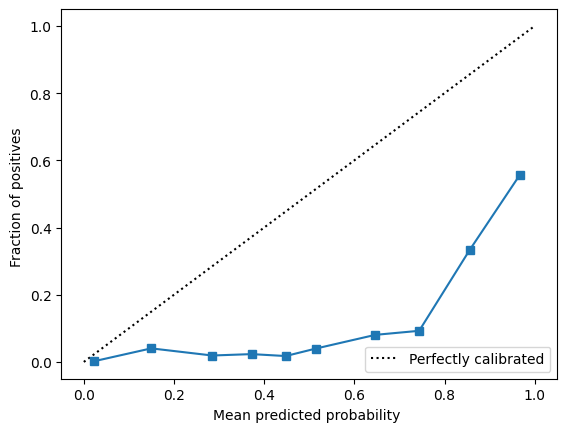

In [86]:
from sklearn.calibration import CalibratedClassifierCV, CalibrationDisplay, calibration_curve
prob_true, prob_pred = calibration_curve(y_test, y_pred_prob, n_bins=10)

disp = CalibrationDisplay(prob_true, prob_pred, y_pred_prob)
disp.plot();

In [87]:
calibrated_clf = CalibratedClassifierCV(pipe, cv=cv)
calibrated_clf.fit(X_train, y_train)

KeyboardInterrupt: 

In [ ]:
y_pred_prob = calibrated_clf.predict_proba(X_test)


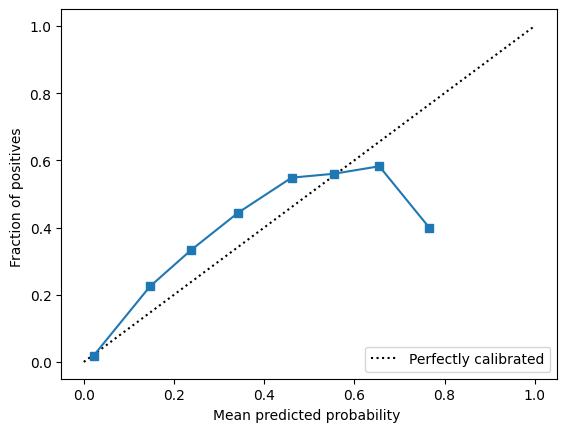

In [58]:
prob_true, prob_pred = calibration_curve(y_test, y_pred_prob[:,1], n_bins=10)

disp = CalibrationDisplay(prob_true, prob_pred, y_pred_prob[:,1])
disp.plot();

### Under Sampling

In [98]:
pip install imbalanced-learn

Note: you may need to restart the kernel to use updated packages.


In [99]:

from imblearn.under_sampling import TomekLinks

In [100]:


tl = TomekLinks()
X_train_res, y_train_res = tl.fit_resample(X_train_transformed, y_train)

print(X_train_res.shape)
print(y_train_res.shape)


(43524, 896)
(43524,)


In [63]:
y_train_res.value_counts(normalize=True)

target_0_1
0    0.962537
1    0.037463
Name: proportion, dtype: float64

### Feature importance

In [ ]:
feature_names = list(X_train.columns)

In [ ]:
from sklearn.inspection import permutation_importance
r = permutation_importance(log_reg, X_train, y_train,
                           n_repeats=5,
                           random_state=0)
for i in r.importances_mean.argsort()[::-1]:
    #if r.importances_mean[i] - 2 * r.importances_std[i] > 0:
    print(f"{feature_names[i]:<8}"
            f"{r.importances_mean[i]:.3f}"
            f" +/- {r.importances_std[i]:.3f}")

KeyboardInterrupt: 

In [ ]:
r.importances_mean

In [ ]:
ft_importance = pd.DataFrame(r.importances_mean, feature_names).reset_index()

In [ ]:
ft_importance.head(10)

In [ ]:
X_train_preprocessed.shape

(44075, 920)

In [88]:
import numpy as np
from sklearn.model_selection import learning_curve

train_sizes = [7500, 10000,15000, 20000, 25000, 30000]

# Get train scores (R2), train sizes, and validation scores using `learning_curve`
train_sizes, train_scores, test_scores = learning_curve(
    estimator=pipe, X=X_train, y=y_train, train_sizes=train_sizes, cv=5, scoring="recall")

# Take the mean of cross-validated train scores and validation scores
train_scores_mean = np.mean(train_scores, axis=1)
test_scores_mean = np.mean(test_scores, axis=1)


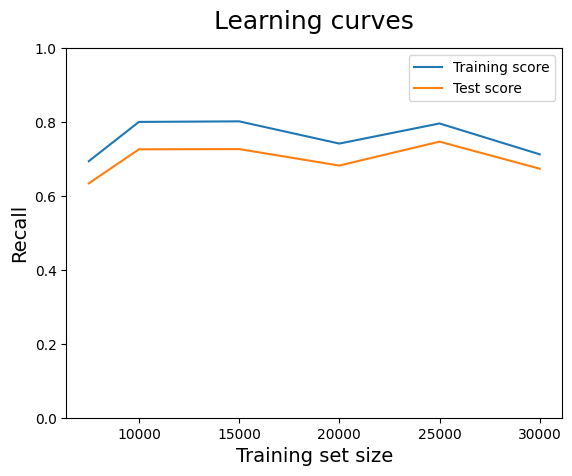

In [89]:
plt.plot(train_sizes, train_scores_mean, label = 'Training score')
plt.plot(train_sizes, test_scores_mean, label = 'Test score')
plt.ylim(0, 1)
plt.ylabel('Recall', fontsize = 14)
plt.xlabel('Training set size', fontsize = 14)
plt.title('Learning curves', fontsize = 18, y = 1.03)
plt.legend()

In [90]:
pip install shap

  Using cached shap-0.49.1-cp310-cp310-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (25 kB)
  Using cached slicer-0.0.8-py3-none-any.whl.metadata (4.0 kB)
  Using cached numba-0.64.0-cp310-cp310-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (2.9 kB)
  Using cached cloudpickle-3.1.2-py3-none-any.whl.metadata (7.1 kB)
  Using cached llvmlite-0.46.0-cp310-cp310-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (5.0 kB)
Using cached shap-0.49.1-cp310-cp310-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (1.0 MB)
Using cached slicer-0.0.8-py3-none-any.whl (15 kB)
Using cached numba-0.64.0-cp310-cp310-manylinux2014_x86_64.manylinux_2_17_x86_64.whl (3.7 MB)
Using cached llvmlite-0.46.0-cp310-cp310-manylinux2014_x86_64.manylinux_2_17_x86_64.whl (56.3 MB)
Using cached cloudpickle-3.1.2-py3-none-any.whl (22 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5/5 [shap]4/5 [shap]]te]
Note: you may need to restart the kernel to use updated packages.


In [66]:
import shap


/home/sophie/.pyenv/versions/3.10.6/envs/convertiq/lib/python3.10/site-packages/shap/plots/_beeswarm.py:1150: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


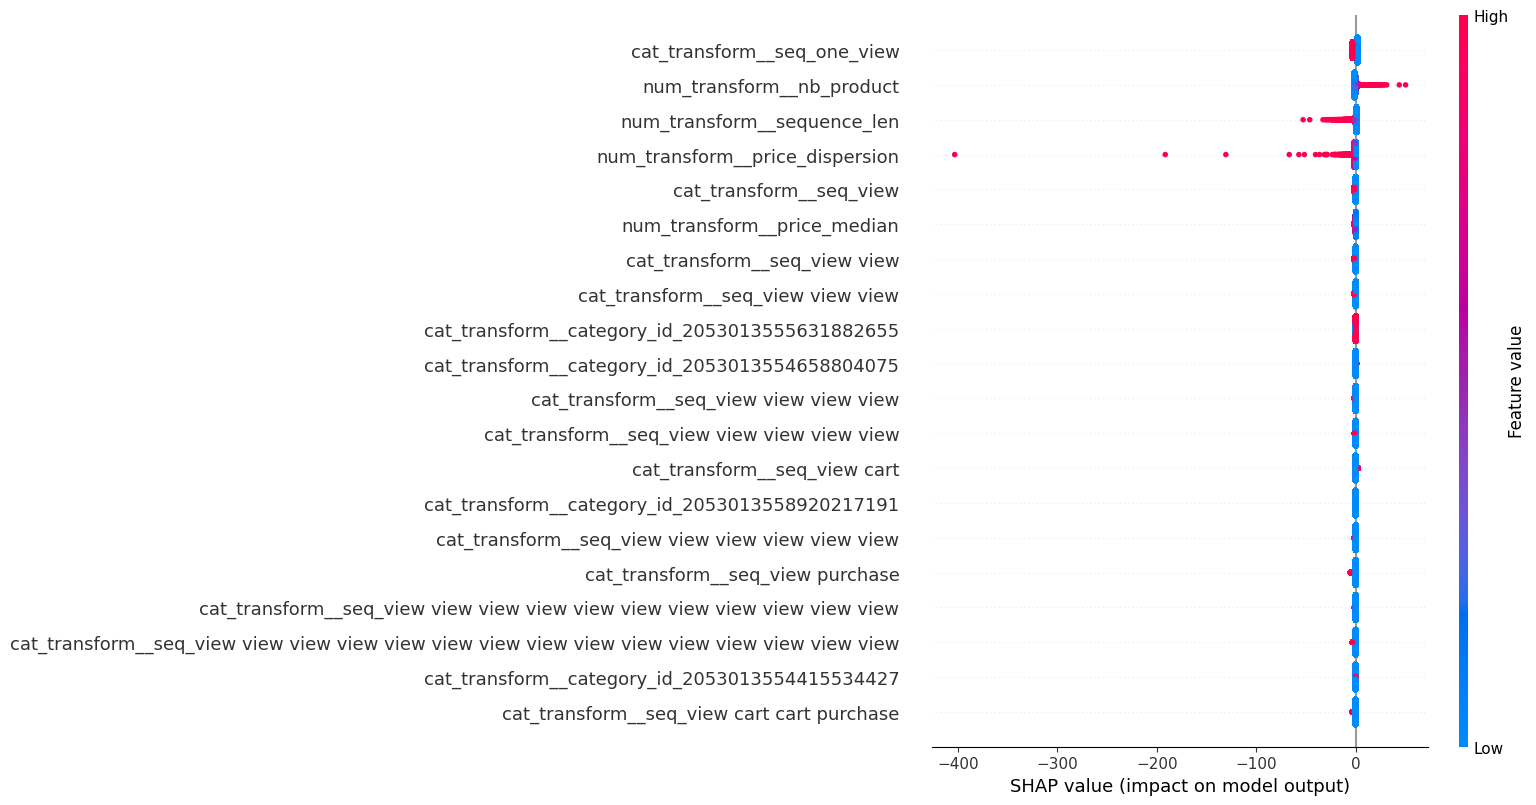

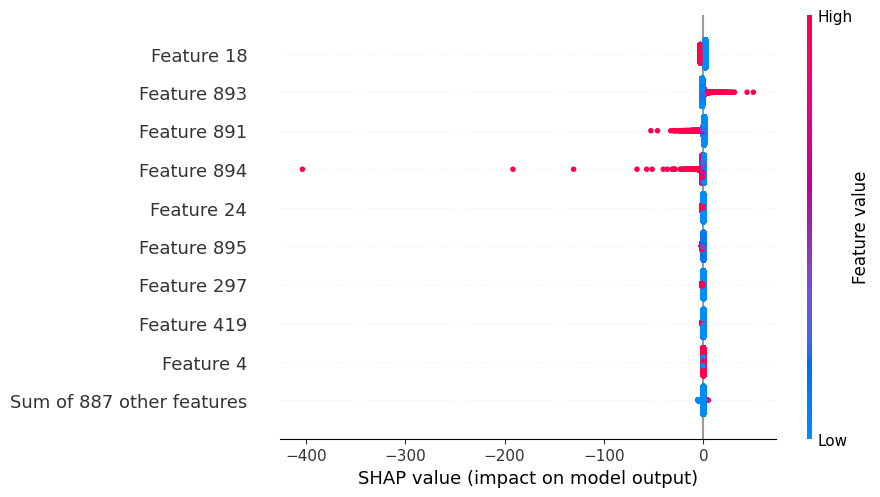

In [ ]:
# Extraire les données transformées et les noms de features
X_train_transformed = pipe.named_steps['preprocessing'].transform(X_train)
feature_names = pipe.named_steps['preprocessing'].get_feature_names_out()

# Passer predict_proba au lieu du pipeline entier
explainer = shap.LinearExplainer(
    pipe.named_steps['classifier'],
    X_train_transformed
)

shap_values = explainer(X_train_transformed)

shap.summary_plot(shap_values, X_train_transformed, feature_names=feature_names)

shap.plots.beeswarm(shap_values)

/home/sophie/.pyenv/versions/3.10.6/envs/convertiq/lib/python3.10/site-packages/shap/plots/_beeswarm.py:1150: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


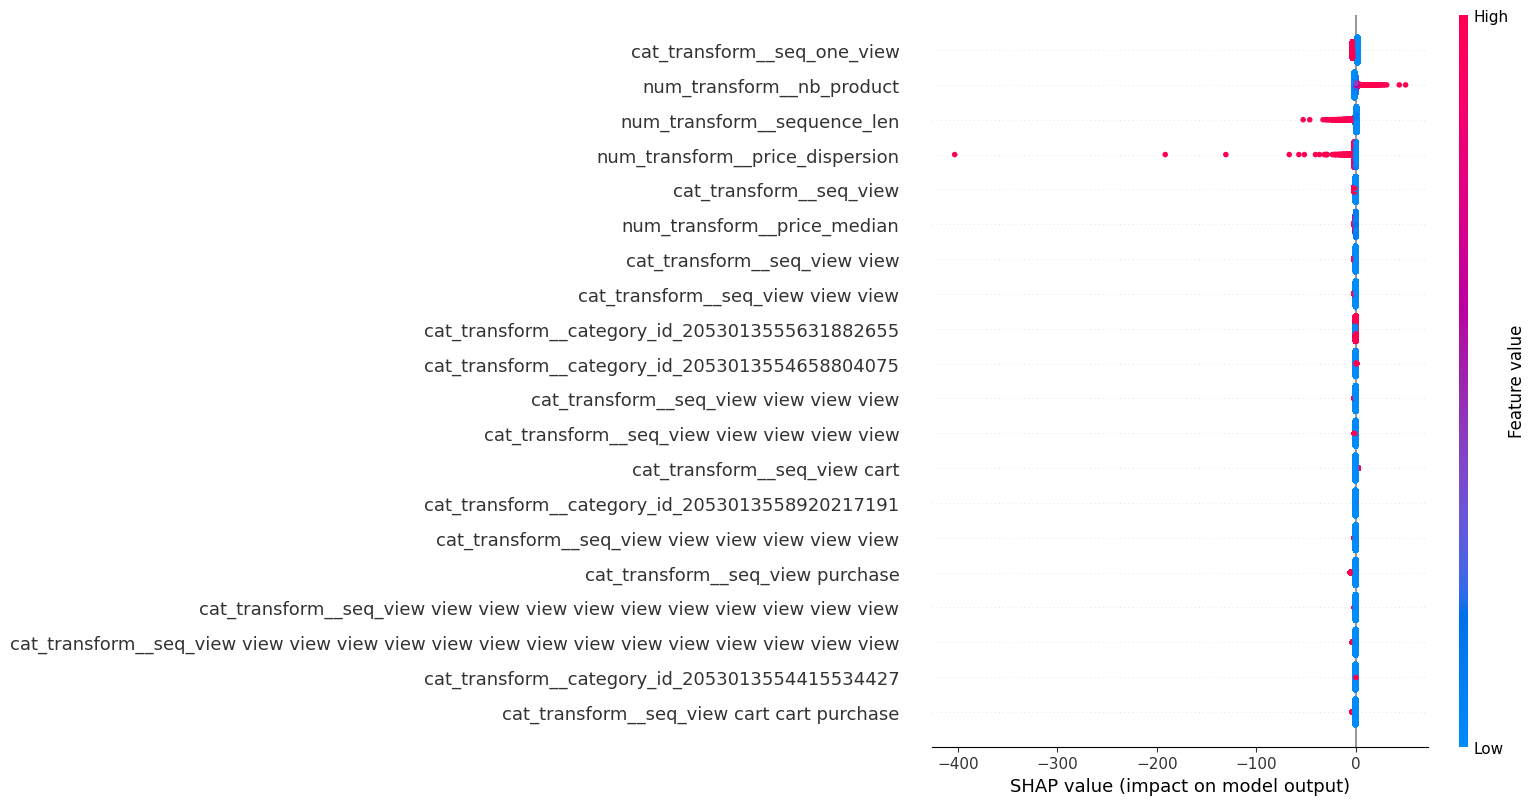

In [68]:
shap.summary_plot(shap_values, X_train_transformed, feature_names=feature_names)


In [71]:
shap.plots.beeswarm(shap_values, feature_names=feature_names)

TypeError: beeswarm() got an unexpected keyword argument 'feature_names'

In [108]:
shap_values.values

array([[-0.00000000e+00, -9.32643352e-04, -2.99004723e-02, ...,
         6.73657813e-01, -1.78237898e-04, -7.95719961e-01],
       [-0.00000000e+00, -9.32643352e-04,  4.68440733e-01, ...,
        -3.11093664e+00,  9.14063657e-05,  2.97709020e+00],
       [-0.00000000e+00, -9.32643352e-04, -2.99004723e-02, ...,
         6.73657813e-01,  6.38132351e-05, -4.52737219e-01],
       ...,
       [-0.00000000e+00, -9.32643352e-04, -2.99004723e-02, ...,
        -1.59709886e+00,  3.83803735e-04,  1.60515923e+00],
       [-0.00000000e+00, -9.32643352e-04, -2.99004723e-02, ...,
         6.73657813e-01, -1.20606676e-04, -4.52737219e-01],
       [-0.00000000e+00, -9.32643352e-04, -2.99004723e-02, ...,
         6.73657813e-01, -1.78237898e-04, -7.95719961e-01]],
      shape=(44075, 912))

In [110]:
shap_df = pd.DataFrame(shap_values.values, columns = feature_names)

# XGBoost

In [ ]:
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

# XGBoost — meilleur choix pour données tabulaires déséquilibrées
xgb = XGBClassifier(
    scale_pos_weight=97/3,  # gère le déséquilibre 3/97
    eval_metric='aucpr',    # optimise sur PR AUC
    random_state=42
)



X_train_transformed = pipe.named_steps['preprocessing'].transform(X_train)
cv_result_xgb = cross_validate(xgb, X_train_transformed, y_train, cv = 5, scoring = ['precision', 'recall', 'f1'])

In [73]:
cv_result_xgb['test_f1'].mean()

np.float64(0.28401015656570755)

In [74]:
cv_result_xgb['test_precision'].mean()

np.float64(0.17193840515395006)

In [75]:
cv_result_xgb['test_recall'].mean()

np.float64(0.8167153426791277)

In [78]:
model_xgb = xgb.fit(X_train_transformed, y_train)

In [81]:
X_test_transformed = pipe.named_steps['preprocessing'].transform(X_test)

In [82]:
print(classification_report(y_test, xgb.predict(X_test_transformed)))

              precision    recall  f1-score   support

           0       0.99      0.84      0.91     10618
           1       0.16      0.83      0.27       401

    accuracy                           0.84     11019
   macro avg       0.58      0.83      0.59     11019
weighted avg       0.96      0.84      0.89     11019



In [101]:
cv = StratifiedKFold(n_splits=5)
cross_v_result = cross_val_score(xgb, X_train_transformed, y_train, cv=cv, scoring="average_precision").mean()

### PR AUC

In [103]:
cross_v_result

np.float64(0.40875549978151166)

In [104]:
y_pred_prob = xgb.predict_proba(X_test_transformed)

In [110]:
precisions, recalls, thresholds = precision_recall_curve(y_test, y_pred_prob[:,1])

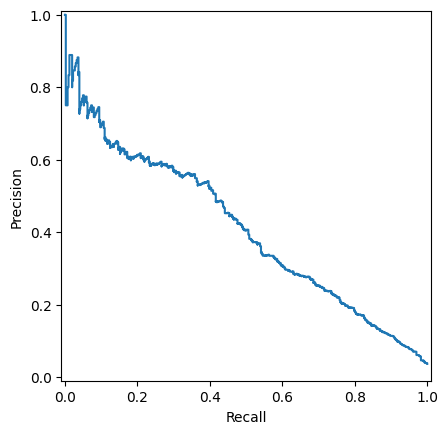

In [111]:
disp = PrecisionRecallDisplay(precision=precision, recall=recall)
disp.plot();

In [114]:
# Trouver le seuil pour recall cible
recall_cible = 0.5
idx = np.argmin(np.abs(recalls - recall_cible))
print(f"Seuil : {thresholds[idx]:.3f}")
print(f"Precision : {precisions[idx]:.3f}")
print(f"Recall : {recalls[idx]:.3f}")

Seuil : 0.867
Precision : 0.405
Recall : 0.501


### Learning curves XGBOOST

In [92]:
import numpy as np
from sklearn.model_selection import learning_curve

train_sizes = [7500, 10000,15000, 20000, 25000, 30000]

# Get train scores (R2), train sizes, and validation scores using `learning_curve`
train_sizes, train_scores, test_scores = learning_curve(
    estimator=xgb, X=X_train_transformed, y=y_train, train_sizes=train_sizes, cv=5, scoring="recall")

# Take the mean of cross-validated train scores and validation scores
train_scores_mean = np.mean(train_scores, axis=1)
test_scores_mean = np.mean(test_scores, axis=1)


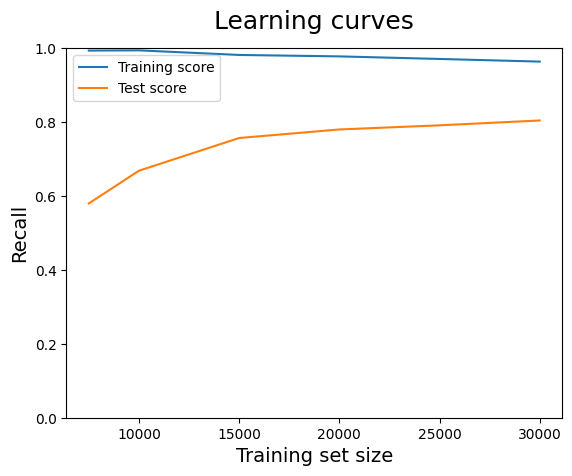

In [93]:
plt.plot(train_sizes, train_scores_mean, label = 'Training score')
plt.plot(train_sizes, test_scores_mean, label = 'Test score')
plt.ylim(0, 1)
plt.ylabel('Recall', fontsize = 14)
plt.xlabel('Training set size', fontsize = 14)
plt.title('Learning curves', fontsize = 18, y = 1.03)
plt.legend()

### XGBOOST Calibration

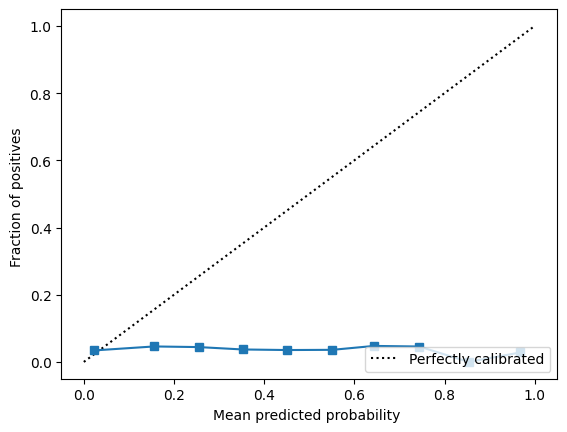

In [94]:
from sklearn.calibration import CalibratedClassifierCV, CalibrationDisplay, calibration_curve
prob_true, prob_pred = calibration_curve(y_test, y_pred_prob, n_bins=10)

disp = CalibrationDisplay(prob_true, prob_pred, y_pred_prob)
disp.plot();

In [96]:
calibrated_clf = CalibratedClassifierCV(xgb, cv=cv)
calibrated_clf.fit(X_train_transformed, y_train)
y_pred_prob = calibrated_clf.predict_proba(X_test_transformed)

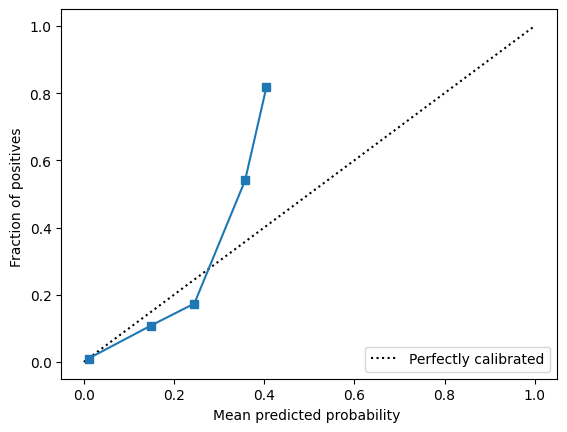

In [97]:
prob_true, prob_pred = calibration_curve(y_test, y_pred_prob[:,1], n_bins=10)

disp = CalibrationDisplay(prob_true, prob_pred, y_pred_prob[:,1])
disp.plot();

### SHAP XGBOOST

In [ ]:
X_test_transformed = pd.DataFrame(
    X_test_transformed,
    columns=feature_names
).astype(float)

explainer = shap.TreeExplainer(model_xgb)
shap_values = explainer(X_test_transformed)


ValueError: could not convert string to float: '[5.4961514E-1]'

In [89]:
X_test_transformed.head()

,cat_transform__category_id_2053013552603594983,cat_transform__category_id_2053013553341792533,cat_transform__category_id_2053013554415534427,cat_transform__category_id_2053013554658804075,cat_transform__category_id_2053013555631882655,cat_transform__category_id_2053013558920217191,cat_transform__category_id_2053013561579406073,cat_transform__category_id_2109094148110811752,cat_transform__seq_cart,cat_transform__seq_cart cart,...,cat_transform__seq_view view view view view view view view view view view view view view view view view view view view view view view view view view view view view view view view view view view view view view view view view view view view view view view view view view view view view view view view view view view view view view view view view view view view view view view view view view,cat_transform__seq_view view view view view view view view view view view view view view view view view view view view view view view view view view view view view view view view view view view view view view view view view view view view view view view view view view view view view view view view view view view view view view view view view view view view view view view view view view view view view view view,cat_transform__seq_view view view view view view view view view view view view view view view view view view view view view view view view view view view view view view view view view view view view view view view view view view view view view view view view view view view view view view view view view view view view view view view view view view view view view view view view view view view view view view view view view view view view view view view,cat_transform__seq_view view view view view view view view view view view view view view view view view view view view view view view view view view view view view view view view view view view view view view view view view view view view view view view view view view view view view view view view view view view view view view view view view view view view view view view view view view view view view view view view view view view view view view view view view view view purchase view view view view view view view view view view view view view view view view view view view view view view view view view view view view view view view view view view view view view view view view view view view view view view,cat_transform__seq_view view view view view view view view view view view view view view view view view view view view view view view view view view view view view view view view view view view view view view view view view view view view view view view view view view view view view view view view view view view view view view view view view view view view view view view view view view view view view view view view view view view view view view view view view view view view view view view view view view view view view view view view view view view view view view view view view view view view view view view view view,num_transform__sequence_len,num_transform__duration_mean_sec,num_transform__nb_product,num_transform__price_dispersion,num_transform__price_median
0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.5,-0.181548,0.333333,1.179701,-0.120800
1,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,-0.011905,0.000000,0.000000,-0.243859
2,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,-0.404762,-0.333333,0.000000,-0.299065
3,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,4.059524,0.000000,0.000000,-0.454074
4,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.125000,0.666667,11.754079,-0.299118
